<a href="https://colab.research.google.com/github/HowardChen0211/gisPy/blob/main/ProblemSets_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProblemSet 0



## Research Question:

- How do two core dimensions of livability, *housing affordability* and *economic security*  vary across California's 58 counties, and do they move together?


## Unit of Analysis
Counties in California (n = 58)

#### Install the package (If needed)

In [1]:
# !pip install geopandas
# !pip install mapclassify

#### Import the package from library

In [2]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd # # GIS / maps
import mapclassify  # required by geopandas for scheme="quantiles"

pd.set_option("display.float_format", "{:,.2f}".format)

# will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'last_expr' # 'last_expr'

#### Load the Geographic Data
These datasets contain shapefile boundaries for CA State, counties and places from the US Census Bureau's 2023 MAF/TIGER database

In [3]:
# The CA Boundaries data can be found at here https://catalog.data.gov/dataset/ca-geographic-boundaries

# -q = quiet; -O = output filename; saves file as CA_Counties_Boundaries.zip

# CA Counties Boundary dataset
! wget -q -O CA_Counties_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/b0007416-a325-4777-9295-368ea6b710e6/download/ca_counties.zip

# CA State Boundary dataset
! wget -q -O CA_State_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/3db1e426-fb51-44f5-82d5-a54d7c6e188b/download/ca_state.zip

# CA Places Boundary dataset
! wget -q -O CA_Places_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/436fc714-831c-4070-b44b-b06dcde6bf18/download/ca_places.zip


for z in ["CA_Counties_Boundaries.zip", "CA_State_Boundaries.zip", "CA_Places_Boundaries.zip"]:
  with zipfile.ZipFile(z, 'r') as zf:
    zf.extractall()

!ls # see what we got

CA_Counties_Boundaries.zip  CA_Places.cpg	     CA_State.dbf
CA_Counties.cpg		    CA_Places.dbf	     CA_State.prj
CA_Counties.dbf		    CA_Places.prj	     CA_State.sbn
CA_Counties.prj		    CA_Places.sbn	     CA_State.sbx
CA_Counties.sbn		    CA_Places.sbx	     CA_State.shp
CA_Counties.sbx		    CA_Places.shp	     CA_State.shp.xml
CA_Counties.shp		    CA_Places.shp.xml	     CA_State.shx
CA_Counties.shp.xml	    CA_Places.shx	     sample_data
CA_Counties.shx		    CA_State_Boundaries.zip
CA_Places_Boundaries.zip    CA_State.cpg


In [4]:
state = gpd.read_file("CA_State.shp")
counties = gpd.read_file("CA_Counties.shp")
cities = gpd.read_file("CA_Places.shp")

print("State:", state.shape, "| Counties:", counties.shape, "| Places:", cities.shape)

State: (1, 19) | Counties: (58, 20) | Places: (1521, 19)


### State Boundary

In [5]:
state.head() # see the first 5 rows

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,56,4,9,06,01779778,06,CA,California,00,G4000,A,"403,467,168,329.00","20,499,799,756.00",+37.1551773,-119.5434183,"5,258,040.98","5,258,040.98","671,892,661,618.00","MULTIPOLYGON (((-13060108.516 3854208.959, -13..."


In [6]:
state.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    1 non-null      int64   
 1   REGION      1 non-null      object  
 2   DIVISION    1 non-null      object  
 3   STATEFP     1 non-null      object  
 4   STATENS     1 non-null      object  
 5   GEOID       1 non-null      object  
 6   STUSPS      1 non-null      object  
 7   NAME        1 non-null      object  
 8   LSAD        1 non-null      object  
 9   MTFCC       1 non-null      object  
 10  FUNCSTAT    1 non-null      object  
 11  ALAND       1 non-null      float64 
 12  AWATER      1 non-null      float64 
 13  INTPTLAT    1 non-null      object  
 14  INTPTLON    1 non-null      object  
 15  Shape_Leng  1 non-null      float64 
 16  Shape_Le_1  1 non-null      float64 
 17  Shape_Area  1 non-null      float64 
 18  geometry    1 non-null      geometry
dtypes: f

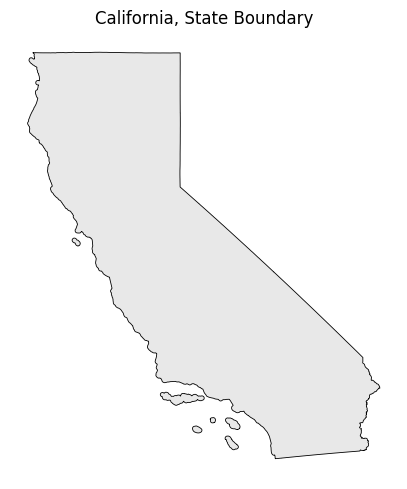

In [7]:
fig, ax = plt.subplots(figsize=(5, 6))
state.plot(ax=ax, color="#e8e8e8", edgecolor="black", linewidth=0.6)
ax.set_title("California, State Boundary")
ax.set_axis_off()
plt.show()

As you can see, it shows the state of California

### Counties Boundary




In [8]:
counties.head() # see the first 5 rows

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,"2,468,694,583.00","23,299,110.00",+39.5769252,-120.5219926,"375,602.76","4,200,449,582.90","POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,"2,499,983,887.00","75,425,434.00",+38.4500161,-121.3404408,"406,584.17","4,205,515,609.97","POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,"7,084,063,392.00","2,729,751,706.00",+34.5370572,-120.0399729,"891,686.75","14,498,407,802.30","MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,"2,641,784,992.00","43,841,871.00",+38.1838996,-120.5614415,"367,005.88","4,356,213,312.52","POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,"4,771,987,962.00","947,345,370.00",+34.3587415,-119.1331432,"527,772.24","8,413,293,072.23","MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


In [9]:
counties.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP     58 non-null     object  
 1   COUNTYFP    58 non-null     object  
 2   COUNTYNS    58 non-null     object  
 3   GEOID       58 non-null     object  
 4   NAME        58 non-null     object  
 5   NAMELSAD    58 non-null     object  
 6   LSAD        58 non-null     object  
 7   CLASSFP     58 non-null     object  
 8   MTFCC       58 non-null     object  
 9   CSAFP       31 non-null     object  
 10  CBSAFP      45 non-null     object  
 11  METDIVFP    7 non-null      object  
 12  FUNCSTAT    58 non-null     object  
 13  ALAND       58 non-null     float64 
 14  AWATER      58 non-null     float64 
 15  INTPTLAT    58 non-null     object  
 16  INTPTLON    58 non-null     object  
 17  Shape_Leng  58 non-null     float64 
 18  Shape_Area  58 non-null     float64 
 19  ge

In [10]:
# Convert the GEOID dtypes
counties["GEOID"] = counties["GEOID"].astype(int) # "06001" -> 6001, to match ACS FIPS

print("Dimensions:", counties.shape)
counties.head()

Dimensions: (58, 20)


,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,6091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,"2,468,694,583.00","23,299,110.00",+39.5769252,-120.5219926,"375,602.76","4,200,449,582.90","POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,6067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,"2,499,983,887.00","75,425,434.00",+38.4500161,-121.3404408,"406,584.17","4,205,515,609.97","POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,6083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,"7,084,063,392.00","2,729,751,706.00",+34.5370572,-120.0399729,"891,686.75","14,498,407,802.30","MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,6009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,"2,641,784,992.00","43,841,871.00",+38.1838996,-120.5614415,"367,005.88","4,356,213,312.52","POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,6111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,"4,771,987,962.00","947,345,370.00",+34.3587415,-119.1331432,"527,772.24","8,413,293,072.23","MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


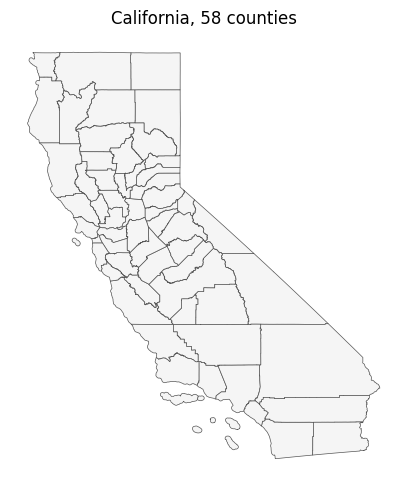

In [11]:
fig, ax = plt.subplots(figsize=(5, 6))
counties.plot(ax=ax, color="#f5f5f5", edgecolor="#555555", linewidth=0.5)
ax.set_title("California, 58 counties")
ax.set_axis_off()
plt.show()

As you can see, it shows 58 counties boundary of California

### Cities Boundary

In [12]:
cities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP     1521 non-null   object  
 1   PLACEFP     1521 non-null   object  
 2   PLACENS     1521 non-null   object  
 3   GEOID       1521 non-null   object  
 4   NAME        1521 non-null   object  
 5   NAMELSAD    1521 non-null   object  
 6   LSAD        1521 non-null   object  
 7   CLASSFP     1521 non-null   object  
 8   PCICBSA     1521 non-null   object  
 9   PCINECTA    1521 non-null   object  
 10  MTFCC       1521 non-null   object  
 11  FUNCSTAT    1521 non-null   object  
 12  ALAND       1521 non-null   float64 
 13  AWATER      1521 non-null   float64 
 14  INTPTLAT    1521 non-null   object  
 15  INTPTLON    1521 non-null   object  
 16  Shape_Leng  1521 non-null   float64 
 17  Shape_Area  1521 non-null   float64 
 18  geometry    1521 non-null   geometry
dty

The Places file mixes incorporated cities (CLASSFP starting with "C") and Census Designated Places (unincorporated, CLASSFP "U"). Only incorporated, active places are kept: Reduced from 1,521 to 482 incorporated cities

In [13]:
mask = cities["CLASSFP"].str.startswith("C", na=False)
cities = cities.loc[mask, ["GEOID", "NAME", "CLASSFP", "geometry"]]

print("Incorporated cities:", len(cities))

Incorporated cities: 482


In [14]:
print("Dimensions:", cities.shape) # Reduced from 1,521 to 482 incorporated cities

# Convert the GEOID dtypes
cities["GEOID"] = cities["GEOID"].astype(int)

cities.head()

Dimensions: (482, 4)


,GEOID,NAME,CLASSFP,geometry
0,666140,San Fernando,C1,"POLYGON ((-13186463.855 4067122.651, -13186256..."
1,614190,Cloverdale,C1,"POLYGON ((-13696207.846 4691208.338, -13696205..."
2,616560,Cotati,C1,"POLYGON ((-13662197.838 4626644.613, -13662188..."
3,665042,San Buenaventura (Ventura),C1,"MULTIPOLYGON (((-13280094.138 4075172.878, -13..."
4,630014,Glendora,C1,"POLYGON ((-13123461.909 4048524.147, -13123461..."


In [15]:
cities["CLASSFP"].value_counts()

,count
CLASSFP,
C1,482


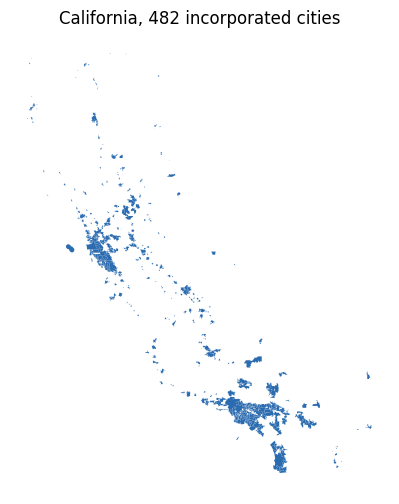

In [16]:
fig, ax = plt.subplots(figsize=(5, 6))
cities.plot(ax=ax, color="#2b6cb0", linewidth=0)
ax.set_title("California, 482 incorporated cities")
ax.set_axis_off()
plt.show()

As you can see, it shows the places of Californiac excluding the Census Designated Places.
And there are three dense clusters(the Bay Area, the Los Angeles basin, and the San Diego coast)

# ProblemSet 1

### Map 1 - A map of counties and municipality boundaries in California

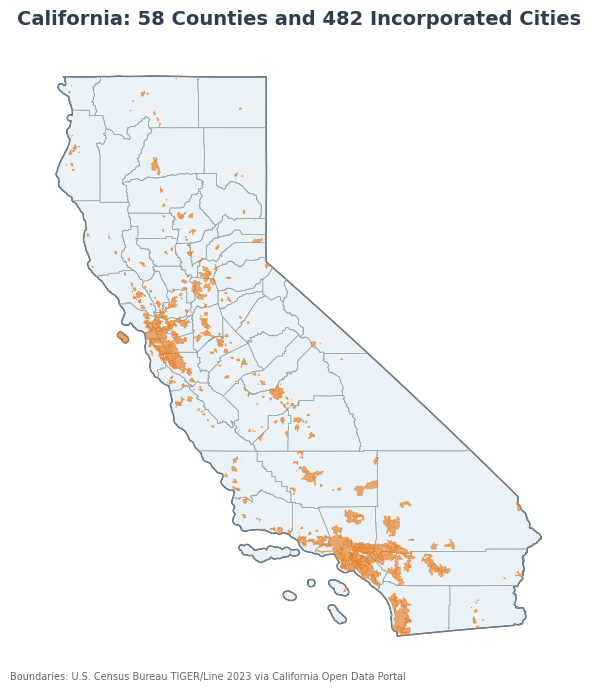

In [17]:
fig, ax = plt.subplots(figsize=(7, 8))

state.plot(ax=ax, color="#EAF2F8", edgecolor="#2C3E50", linewidth=1.0)

counties.plot(ax=ax, color="none", edgecolor="#95A5A6", linewidth=0.45)

cities.plot(ax=ax, color="#E67E22", edgecolor="#e67e22", alpha=0.65, linewidth=0.35)

ax.set_title("California: 58 Counties and 482 Incorporated Cities", fontsize=14, fontweight="bold", color="#2C3E50")

ax.set_axis_off()

fig.text(0.10, 0.09, "Boundaries: U.S. Census Bureau TIGER/Line 2023 via California Open Data Portal", fontsize=7, color="#666666")

plt.show()

## ACS(American Community Survey) Data

Soure: https://www.socialexplorer.com/data-library/2 2020--2024 (5-Year-Estimates)

#### Load the data #1 (Population, Household Income, House Value)



In [18]:
# population at County level
pop = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/Population_2024.csv", skiprows=[1])
pop.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Total Population,Population Density (Per Sq. Mile),Area (Land).1
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,1649473,"2,236.70",737.46
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,1616,2.19,738.34
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,41428,69.68,594.58
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,207929,127.06,"1,636.51"
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,46248,45.34,"1,020.02"


In [19]:
pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   FIPS                               58 non-null     int64  
 1   GeoLevel                           58 non-null     object 
 2   NAME                               58 non-null     object 
 3   Qualified Area Name                58 non-null     object 
 4   Area (Land)                        58 non-null     int64  
 5   Area (Water)                       58 non-null     int64  
 6   Total Population                   58 non-null     int64  
 7   Population Density (Per Sq. Mile)  58 non-null     float64
 8   Area (Land).1                      58 non-null     float64
dtypes: float64(2), int64(4), object(3)
memory usage: 4.2+ KB


In [20]:
# Median household income at County level
household_income = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/household_income_2024.csv", skiprows=[1])
household_income.rename(columns={"Median Household Income (In 2024 Inflation Adjusted Dollars)": "Median Household Income"}, inplace=True)
household_income.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Median Household Income
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,129367
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,105521
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,88044
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,67928
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,78647


In [21]:
household_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   FIPS                     58 non-null     int64 
 1   GeoLevel                 58 non-null     object
 2   NAME                     58 non-null     object
 3   Qualified Area Name      58 non-null     object
 4   Area (Land)              58 non-null     int64 
 5   Area (Water)             58 non-null     int64 
 6   Median Household Income  58 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 3.3+ KB


In [22]:
# Median owner-occupied house value at County level
house_val = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/housevalue_2024.csv", skiprows=[1])
house_val.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Median House Value
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,1090100
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,590200
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,449800
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,424700
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,457200


In [23]:
house_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   FIPS                 58 non-null     int64 
 1   GeoLevel             58 non-null     object
 2   NAME                 58 non-null     object
 3   Qualified Area Name  58 non-null     object
 4   Area (Land)          58 non-null     int64 
 5   Area (Water)         58 non-null     int64 
 6   Median House Value   58 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 3.3+ KB


#### Clean the data

In [24]:
census_house = (
    pop[["FIPS", "NAME", "Total Population", "Population Density (Per Sq. Mile)"]]
    .merge(household_income[["FIPS", "Median Household Income"]], on="FIPS", how="outer", validate="one_to_one")
    .merge(house_val[["FIPS", "Median House Value"]], on="FIPS", how="outer", validate="one_to_one")
)

num_cols = ["Total Population", "Population Density (Per Sq. Mile)", "Median Household Income", "Median House Value"]
census_house[num_cols] = census_house[num_cols].apply(pd.to_numeric, errors="coerce") # to numeric types, if missing values found will fill it NaN

In [25]:
census_house.rename(columns={"Total Population": "TPOP",
                     "Population Density (Per Sq. Mile)": "POPDEN",
                     "Median Household Income": "MED_INC",
                     "Median House Value": "MED_HVAL"}, inplace = True)

In [26]:
# Before
census_house.head()

,FIPS,NAME,TPOP,POPDEN,MED_INC,MED_HVAL
0,6001,"Alameda County, California",1649473,"2,236.70",129367,1090100
1,6003,"Alpine County, California",1616,2.19,105521,590200
2,6005,"Amador County, California",41428,69.68,88044,449800
3,6007,"Butte County, California",207929,127.06,67928,424700
4,6009,"Calaveras County, California",46248,45.34,78647,457200


In [27]:
# change the NAME to make sure consistency
census_house["NAME"] = census_house["NAME"].str.split(",").str[0]

In [28]:
# After
census_house.head()

,FIPS,NAME,TPOP,POPDEN,MED_INC,MED_HVAL
0,6001,Alameda County,1649473,"2,236.70",129367,1090100
1,6003,Alpine County,1616,2.19,105521,590200
2,6005,Amador County,41428,69.68,88044,449800
3,6007,Butte County,207929,127.06,67928,424700
4,6009,Calaveras County,46248,45.34,78647,457200


## California Unemployment Data
Source: Social explorer
American Community Survey 2020--2024 (5-Year-Estimates) https://www.socialexplorer.com/reports/socialexplorer/en/report/bac15980-b308-11f1-9512-c38da70940e6

#### Load the data #2 (labor force and unemp)

In [29]:
# Labor Force 16 Years and Over
unemployment = pd.read_csv("https://github.com/HowardChen0211/gisPy/raw/refs/heads/main/CA_UnemploymentRate.csv")
unemployment.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Civilian Population in Labor Force 16 Years and Over,Civilian Population in Labor Force 16 Years and Over: Employed,Civilian Population in Labor Force 16 Years and Over: Unemployed
0,Geo_FIPS,_geo_level_,Geo_NAME,Geo_qname,Geo_AREALAND,Geo_AREAWATER,SE_A17005_001,SE_A17005_002,SE_A17005_003
1,06001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,908995,860129,48866
2,06003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,837,800,37
3,06005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,17257,16325,932
4,06007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,100743,93228,7515


In [30]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 9 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   FIPS                                                              59 non-null     object
 1   GeoLevel                                                          59 non-null     object
 2   NAME                                                              59 non-null     object
 3   Qualified Area Name                                               59 non-null     object
 4   Area (Land)                                                       59 non-null     object
 5   Area (Water)                                                      59 non-null     object
 6   Civilian Population in Labor Force 16 Years and Over              59 non-null     object
 7   Civilian Population in Labor Force 16 Years and

#### Clean the data

In [31]:
# Choose the columns I need
unemployment = unemployment[["FIPS",
                             "NAME",
                             'Civilian Population in Labor Force 16 Years and Over',
                             'Civilian Population in Labor Force 16 Years and Over: Employed',
                             'Civilian Population in Labor Force 16 Years and Over: Unemployed']].iloc[1:, :]

In [32]:
# Rename the columns
unemployment.rename(columns={"NAME":"County",
                             "Civilian Population in Labor Force 16 Years and Over": "Labor Force",
                             "Civilian Population in Labor Force 16 Years and Over: Employed": "Employed",
                             'Civilian Population in Labor Force 16 Years and Over: Unemployed':"Unemployed"}, inplace=True)

In [33]:
# Convert the FIPS dtypes
unemployment["FIPS"] = unemployment["FIPS"].astype(int)

In [34]:
# get rid of ' County, California'
unemployment["County"] = unemployment["County"].str.replace(" County, California", "")
unemployment.head()

,FIPS,County,Labor Force,Employed,Unemployed
1,6001,Alameda,908995,860129,48866
2,6003,Alpine,837,800,37
3,6005,Amador,17257,16325,932
4,6007,Butte,100743,93228,7515
5,6009,Calaveras,19422,18545,877


In [35]:
# Convert the data type
unemployment['Labor Force'] = unemployment['Labor Force'].astype(int)
unemployment['Employed'] = unemployment['Employed'].astype(int)
unemployment['Unemployed'] = unemployment['Unemployed'].astype(int)
unemployment['Rate'] = unemployment['Unemployed'] / unemployment['Labor Force'] * 100

unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 1 to 58
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FIPS         58 non-null     int64  
 1   County       58 non-null     object 
 2   Labor Force  58 non-null     int64  
 3   Employed     58 non-null     int64  
 4   Unemployed   58 non-null     int64  
 5   Rate         58 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.8+ KB


In [36]:
unemployment.head()

,FIPS,County,Labor Force,Employed,Unemployed,Rate
1,6001,Alameda,908995,860129,48866,5.38
2,6003,Alpine,837,800,37,4.42
3,6005,Amador,17257,16325,932,5.40
4,6007,Butte,100743,93228,7515,7.46
5,6009,Calaveras,19422,18545,877,4.52


In [37]:
print("rows:", len(unemployment), "| missing:", unemployment.isna().sum().sum(), "| duplicated", unemployment.duplicated().sum())

rows: 58 | missing: 0 | duplicated 0


### Join 1 and Join 2 onto the county boundaries

Both joins use the 5-digit county FIPS code (`GEOID` = `FIPS`)

In [38]:
def check_outer(left, right, left_on, right_on):
  check = pd.merge(left, right, left_on=left_on, right_on=right_on, how="outer", indicator=True)
  print(check["_merge"].value_counts().to_string(), "\n")

print("Join 1:"); check_outer(counties, census_house, "GEOID", "FIPS")
print("Join 2:"); check_outer(counties, unemployment, "GEOID", "FIPS")

Join 1:
_merge
both          58
left_only      0
right_only     0 

Join 2:
_merge
both          58
left_only      0
right_only     0 



In [39]:
gdf = (
    counties
    .merge(census_house.drop(columns="NAME"), left_on="GEOID", right_on="FIPS", how="inner", validate="one_to_one")  # Join 1
    .drop(columns="FIPS")
    .merge(unemployment, left_on="GEOID", right_on="FIPS", how="inner", validate="one_to_one")                       # Join 2
    .drop(columns="FIPS")
)

gdf.shape

(58, 29)

In [40]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   STATEFP      58 non-null     object  
 1   COUNTYFP     58 non-null     object  
 2   COUNTYNS     58 non-null     object  
 3   GEOID        58 non-null     int64   
 4   NAME         58 non-null     object  
 5   NAMELSAD     58 non-null     object  
 6   LSAD         58 non-null     object  
 7   CLASSFP      58 non-null     object  
 8   MTFCC        58 non-null     object  
 9   CSAFP        31 non-null     object  
 10  CBSAFP       45 non-null     object  
 11  METDIVFP     7 non-null      object  
 12  FUNCSTAT     58 non-null     object  
 13  ALAND        58 non-null     float64 
 14  AWATER       58 non-null     float64 
 15  INTPTLAT     58 non-null     object  
 16  INTPTLON     58 non-null     object  
 17  Shape_Leng   58 non-null     float64 
 18  Shape_Area   58 non-null

## Map 2 - where people, money, and expensive homes are

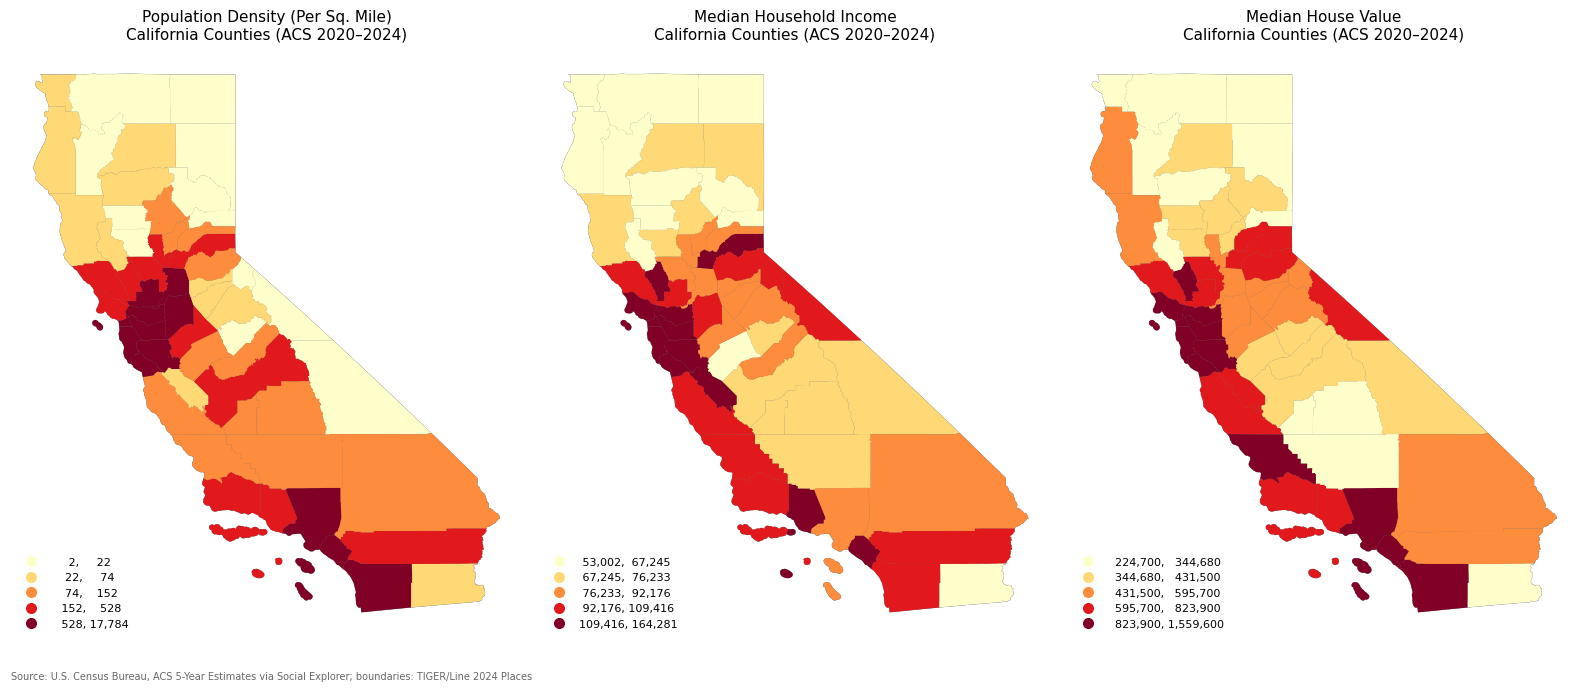

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

maps = [
    ('POPDEN', 'Population Density (Per Sq. Mile)'),
    ('MED_INC', 'Median Household Income'),
    ("MED_HVAL", "Median House Value")
]

for ax, (col, title) in zip(axes, maps):
    counties.plot(ax = ax, color='#2a2a2e', edgecolor='#999999', linewidth=0.3)
    gdf.plot(
        ax=ax,
        column=col, # Data to plot
        legend=True,
        cmap='YlOrRd', # color palette
        scheme='quantiles',
        k=5,
        linewidth=0.2,
        legend_kwds={'fmt': '{:,.0f}', 'loc': 'lower left',
                     'markerscale': 0.8, 'frameon': False, 'fontsize': 8}
    )
    ax.set_title(f'{title}\nCalifornia Counties (ACS 2020–2024)', fontsize=11)
    ax.set_axis_off()

fig.text(0.01, 0.02,
         'Source: U.S. Census Bureau, ACS 5-Year Estimates via Social Explorer; '
         'boundaries: TIGER/Line 2024 Places',
         fontsize=7, color='#666666')

fig.tight_layout()
plt.show()

It shows that California's population density, household income, and housing prices are highly clustered in the Bay Area and the Los Angeles-San Diego along the coast. The San Francisco region ranks at the highest level in all three indicators, while the Central Valley and the northern inland counties are consistently lower.

### Housing Price-to-Income Ratio

In [42]:
gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,geometry,TPOP,POPDEN,MED_INC,MED_HVAL,County,Labor Force,Employed,Unemployed,Rate
0,06,091,00277310,6091,Sierra,Sierra County,06,H1,G4020,None,...,"POLYGON ((-13431319.751 4821511.426, -13431312...",2746,2.88,63355,331900,Sierra,1243,1086,157,12.63
1,06,067,00277298,6067,Sacramento,Sacramento County,06,H1,G4020,472,...,"POLYGON ((-13490651.476 4680831.603, -13490511...",1594006,"1,651.34",92175,534200,Sacramento,805946,751850,54096,6.71
2,06,083,00277306,6083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,...,"MULTIPOLYGON (((-13440081.316 4150394.004, -13...",443701,162.29,98161,790700,Santa Barbara,219992,205874,14118,6.42
3,06,009,01675885,6009,Calaveras,Calaveras County,06,H1,G4020,None,...,"POLYGON ((-13428575.483 4627725.227, -13428534...",46248,45.34,78647,457200,Calaveras,19422,18545,877,4.52
4,06,111,00277320,6111,Ventura,Ventura County,06,H1,G4020,348,...,"MULTIPOLYGON (((-13283668.94 4059436.934, -132...",837469,454.95,109797,822700,Ventura,431630,406900,24730,5.73


In [43]:
gdf["Price2Income"] = gdf["MED_HVAL"] / gdf["MED_INC"]  # price-to-income ratio (×)

gdf[["TPOP", "MED_INC", "MED_HVAL", "Price2Income", "Rate"]].describe().T

,count,mean,std,min,25%,50%,75%,max
TPOP,58.00,"677,368.57","1,440,482.28","1,616.00","48,310.50","187,049.00","695,252.50","9,808,667.00"
MED_INC,58.00,"89,387.00","25,996.77","53,002.00","68,172.00","83,473.00","105,309.25","164,281.00"
MED_HVAL,58.00,"604,112.07","322,948.05","224,700.00","361,750.00","481,100.00","792,725.00","1,559,600.00"
Price2Income,58.00,6.42,1.56,3.78,5.27,5.92,7.51,10.11
Rate,58.00,7.01,2.13,2.48,5.45,6.47,8.30,12.63


In [44]:
# tiny labor forces
gdf.loc[gdf["Labor Force"] < 5000, ["NAME", "Labor Force", "Rate"]].sort_values("Labor Force")

,NAME,Labor Force,Rate
25,Alpine,837,4.42
0,Sierra,1243,12.63
35,Modoc,3368,7.60


Three counties (Alpine, Sierra, Modoc) have fewer than 5,000 people in the labor force. Sierra's 12.6% unemployment rests on about 160 unemployed people, so its true rate could be several points higher or lower.

## Map 3 - Housing Burden: Price-to-Income Ratio

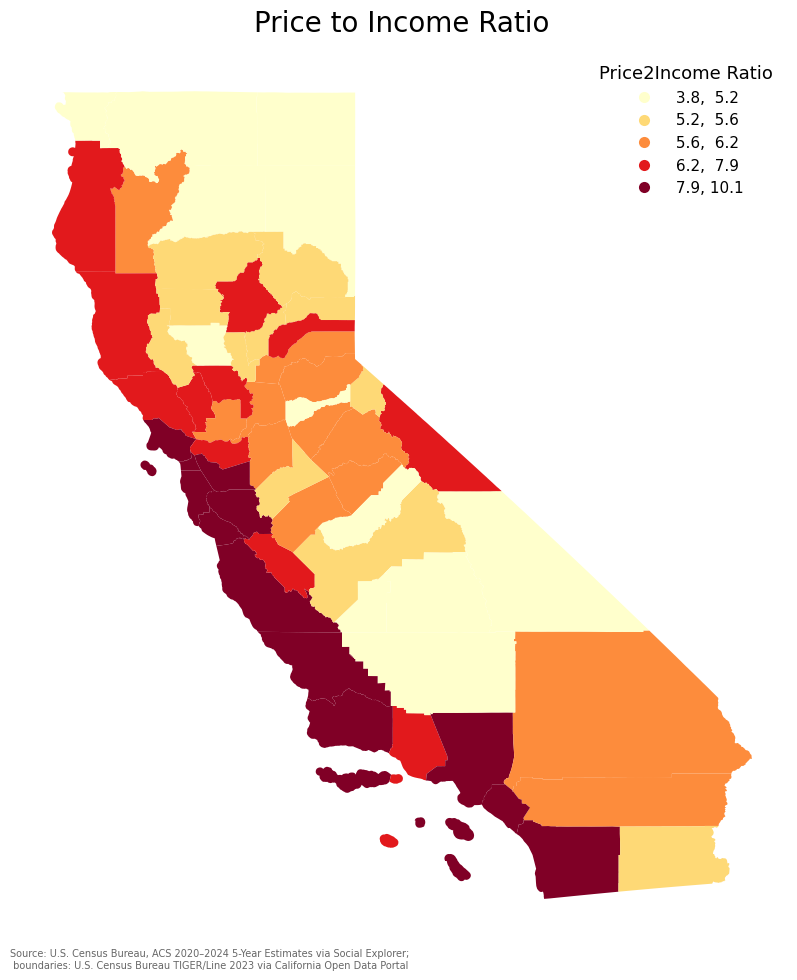

In [45]:
# Source: https://geopandas.org/en/stable/docs/user_guide/mapping.html

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

gdf.plot(
    ax=ax,
    column="Price2Income", # Data to plot
    cmap='YlOrRd', # color palette
    legend=True,
    scheme='quantiles', # k = 5, Number of classes defalut is 5
    linewidth=0.5,
    legend_kwds={"title": "Price2Income Ratio", 'fmt': '{:.1f}', 'loc': 'upper right',
                  'markerscale': 0.8, 'frameon': False, 'fontsize': 11, "title_fontsize": 13, 'edgecolor':"black"}
)

ax.set_title("Price to Income Ratio",
             fontsize=20, pad=14)


fig.text(0.01, 0.02,
         'Source: U.S. Census Bureau, ACS 2020–2024 5-Year Estimates via Social Explorer; '
         '\n boundaries: U.S. Census Bureau TIGER/Line 2023 via California Open Data Portal',
         fontsize=7, color='#666666')

ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

It shows that California counties have substantial differences in their price-to-income ratios, ranging from about 3.8 to 10.1. Counties with darker shading have higher ratio, indicating that housing is less affordable relative to local income compared with counties.

In [46]:
gdf.nlargest(5, "Price2Income")[["NAME", "MED_INC", "MED_HVAL", "Price2Income"]]

,NAME,MED_INC,MED_HVAL,Price2Income
11,Marin,149091,1507300,10.11
10,San Francisco,140970,1394500,9.89
53,San Mateo,158855,1559600,9.82
5,Los Angeles,90112,834200,9.26
55,Santa Cruz,111093,1027500,9.25


In [47]:
gdf.nsmallest(5, "Price2Income")[["NAME", "MED_INC", "MED_HVAL", "Price2Income"]]

,NAME,MED_INC,MED_HVAL,Price2Income
35,Modoc,59455,224700,3.78
13,Lassen,67403,265300,3.94
7,Kings,70995,324300,4.57
45,Tulare,71300,330100,4.63
19,Inyo,73991,348700,4.71


A typical home in Marin costs about **10 years** of the typical household's income; in Modoc it costs under **4**.

## Map 4 - Job Burden: County Unemployment Rate

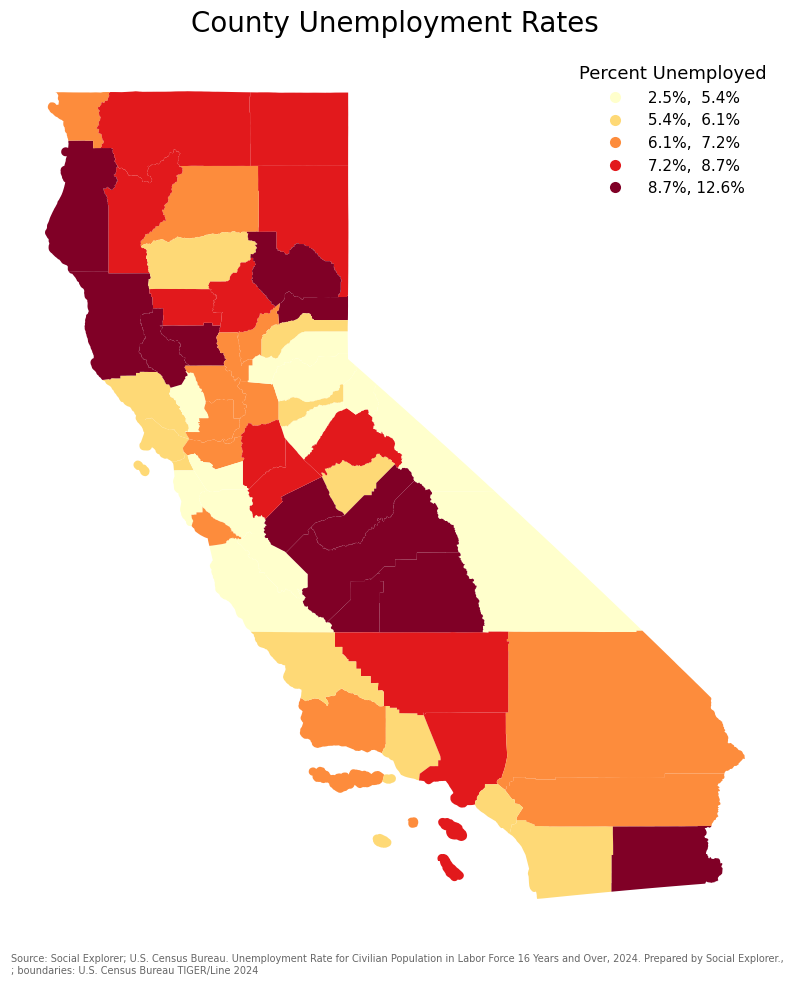

In [48]:
# Source: https://geopandas.org/en/stable/docs/user_guide/mapping.html

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

gdf.plot(
    ax=ax,
    column="Rate", # Data to plot
    cmap='YlOrRd', # color palette
    legend=True,
    scheme='quantiles', # k = 5, Number of classes defalut is 5
    linewidth=0.5,
    legend_kwds={"title": "Percent Unemployed", 'fmt': '{:.1f}%', 'loc': 'upper right',
                  'markerscale': 0.8, 'frameon': False, 'fontsize': 11, "title_fontsize": 13}
)


ax.set_title("County Unemployment Rates",
             fontsize=20, pad=14)


fig.text(0.02, 0.015,
         "Source: Social Explorer; U.S. Census Bureau. Unemployment Rate for Civilian Population in Labor Force 16 Years and Over, 2024. Prepared by Social Explorer., "
         "\n; boundaries: U.S. Census Bureau TIGER/Line 2024",
         fontsize=7, color="#666666")

ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

This map is close to a negative of Map 3. The darkest counties run down the middle of CA and into Imperial on the Mexican border, where unemployment reaches 10-12.5%, and up the North Coast. The Bay Area tech counties and the eastern Sierra counties have the lowest rates.

## References

**Data**
1. U.S. Census Bureau, TIGER/Line 2023 — CA state, county, and places boundaries, via California Open Data Portal: https://data.ca.gov/dataset/ca-geographic-boundaries
2. Social Explorer; U.S. Census Bureau. Total Population (A00001), ACS 2024 5-Year. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A00001
3. Social Explorer; U.S. Census Bureau. Population Density (A00002), ACS 2024 5-Year. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A00002
4. Social Explorer; U.S. Census Bureau. Median Household Income (A14006), ACS 2024 5-Year. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A14006
5. Social Explorer; U.S. Census Bureau. Median House Value (A10036), ACS 2024 5-Year. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A10036
6. Social Explorer; U.S. Census Bureau. Employment Status for Civilian Population in Labor Force 16+ (A17005), ACS 2024 5-Year. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A17005

7. List of counties in California:
https://en.wikipedia.org/wiki/List_of_counties_in_California

8. List of municipalities in California:
 https://en.wikipedia.org/wiki/List_of_municipalities_in_California

9. List of census-designated places in California:
https://en.wikipedia.org/wiki/List_of_census-designated_places_in_California